In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load cleaned dataset
df = pd.read_csv("Nike_Sales_cleaned.csv")

C:\Users\Shrey\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## Sales Trend Analysis (Revenue Over Time)

In [2]:
# Convert Order_Date safely
df['Order_Date'] = pd.to_datetime(df['Order_Date'], errors='coerce', dayfirst=True)

In [3]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'], errors='coerce', format='mixed')

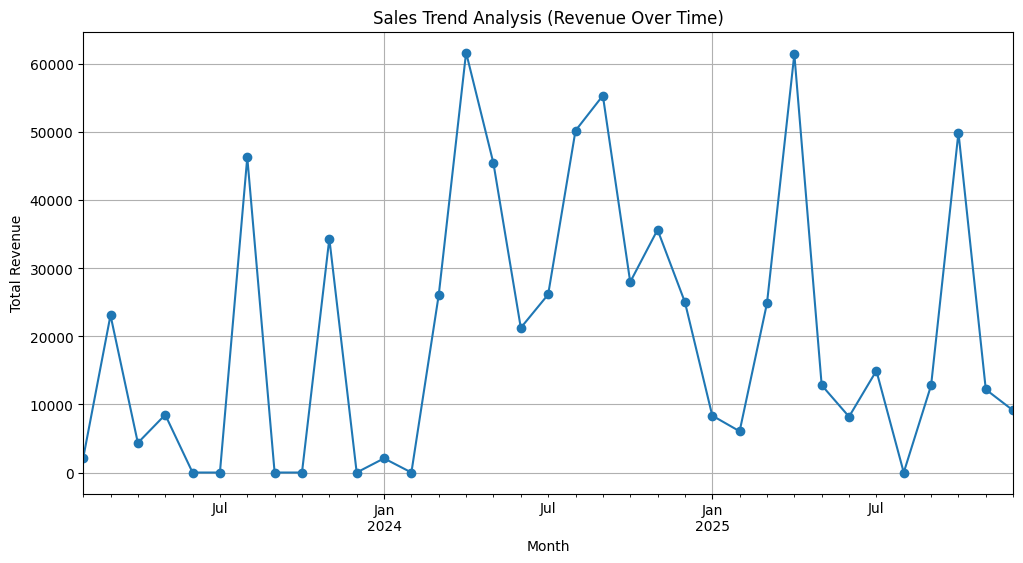

In [4]:
# Parse dates correctly
df['Order_Date'] = pd.to_datetime(df['Order_Date'], errors='coerce', dayfirst=True)

# Group by month
df['Month'] = df['Order_Date'].dt.to_period('M')
monthly_revenue = df.groupby('Month')['Revenue_Calc'].sum()

# Plot
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
monthly_revenue.plot(kind='line', marker='o')
plt.title("Sales Trend Analysis (Revenue Over Time)")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.grid(True)
plt.show()

## Product Line Performance Analysi

In [5]:

# Group by Product Line
product_perf = df.groupby('Product_Line').agg({
    'Revenue_Calc':'sum',
    'Profit_Recalc':'sum'
}).sort_values('Revenue_Calc', ascending=False)

print(product_perf)

              Revenue_Calc  Profit_Recalc
Product_Line                             
Lifestyle     1.427774e+06  107407.142343
Training      1.273430e+06  164941.049944
Basketball    1.208381e+06  146287.579911
Soccer        1.205377e+06  144141.378409
Running       9.834163e+05   78750.925236


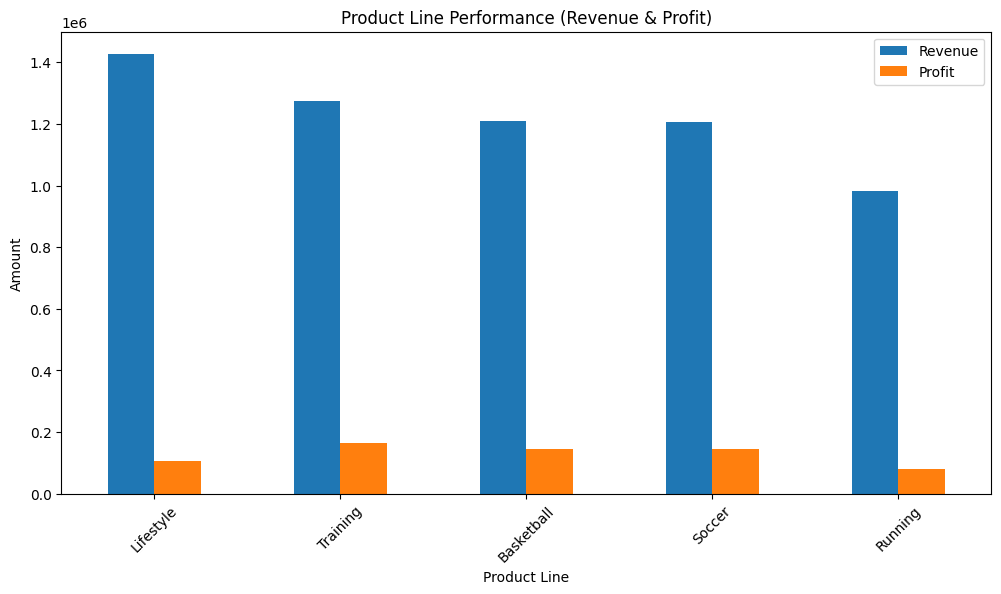

In [6]:
# Plot Revenue & Profit by Product Line
product_perf.plot(kind='bar', figsize=(12,6))
plt.title("Product Line Performance (Revenue & Profit)")
plt.xlabel("Product Line")
plt.ylabel("Amount")
plt.xticks(rotation=45)
plt.legend(["Revenue", "Profit"])
plt.show()

## Top Products Analysis

In [7]:
# Group by Product Name
top_products = df.groupby('Product_Name').agg({
    'Units_Sold':'sum',
    'Revenue_Calc':'sum'
}).sort_values('Units_Sold', ascending=False)

print(top_products.head(10))  # Top 10 products by units sold

                  Units_Sold   Revenue_Calc
Product_Name                               
Dunk Low               109.0  489915.638437
Zoom Freak              95.0  396931.597360
SuperRep Go             92.0  309590.831535
Blazer Mid              91.0  370659.706977
Premier III             90.0  325703.706136
Flex Trainer            87.0  412272.021678
Phantom GT              86.0  300991.875481
LeBron 20               84.0  339290.240912
ZoomX Invincible        78.0  310577.802131
Free RN                 78.0  268922.533193


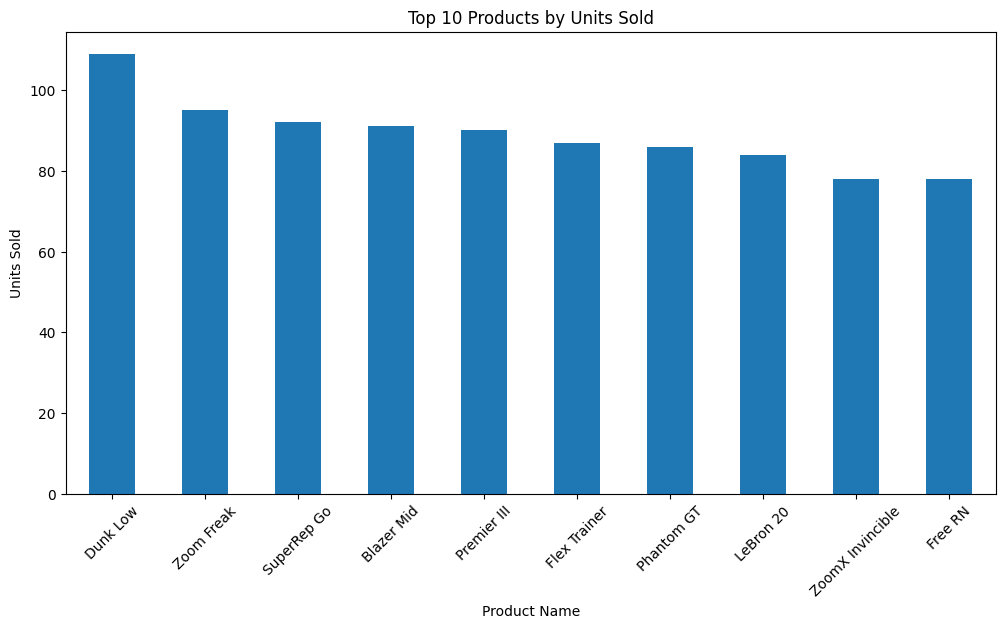

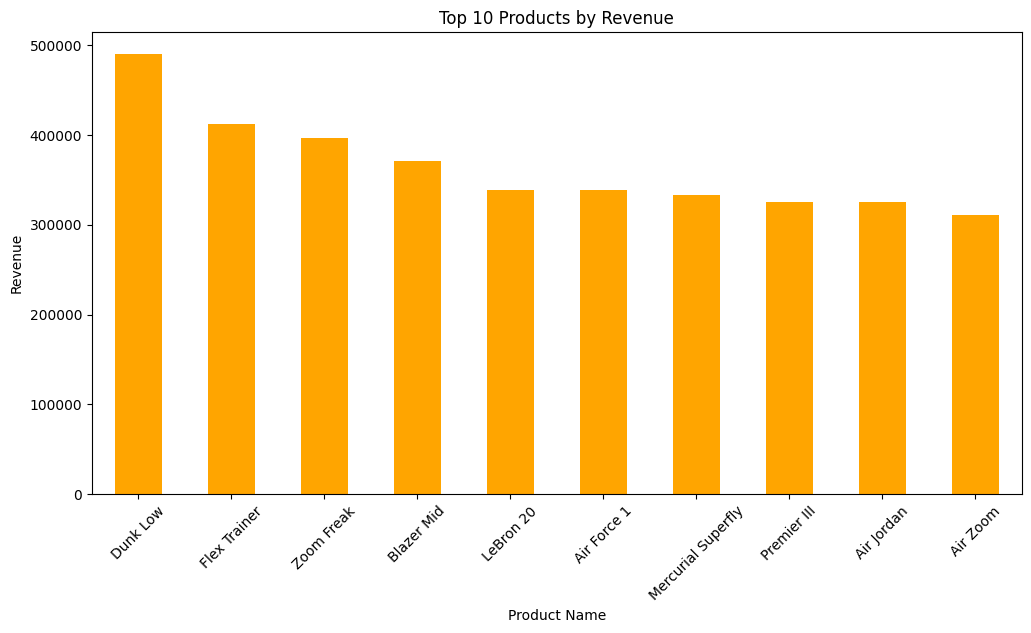

In [8]:
# Top 10 by Units Sold
top_units = top_products.sort_values('Units_Sold', ascending=False).head(10)

plt.figure(figsize=(12,6))
top_units['Units_Sold'].plot(kind='bar')
plt.title("Top 10 Products by Units Sold")
plt.xlabel("Product Name")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.show()

# Top 10 by Revenue
top_revenue = top_products.sort_values('Revenue_Calc', ascending=False).head(10)

plt.figure(figsize=(12,6))
top_revenue['Revenue_Calc'].plot(kind='bar', color='orange')
plt.title("Top 10 Products by Revenue")
plt.xlabel("Product Name")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

##  Discount Effectiveness Analysis.

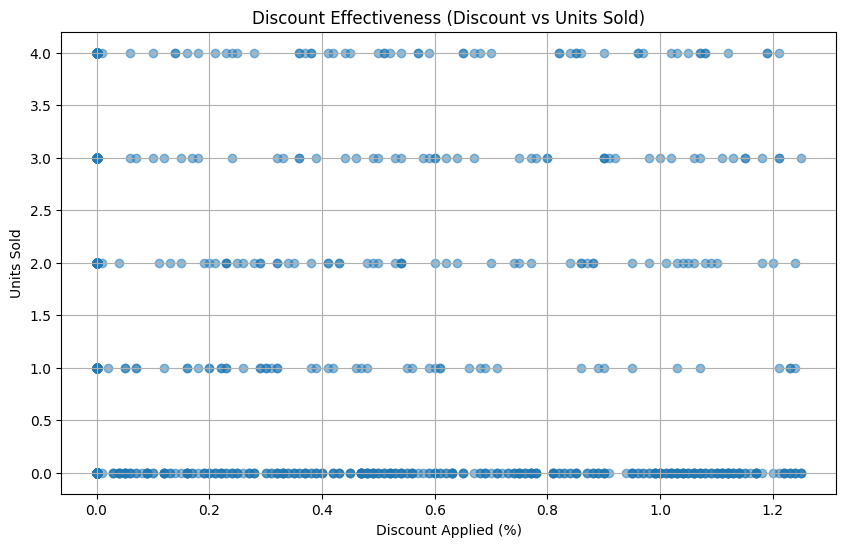

In [9]:
plt.figure(figsize=(10,6))
plt.scatter(df['Discount_Applied'], df['Units_Sold'], alpha=0.5)
plt.title("Discount Effectiveness (Discount vs Units Sold)")
plt.xlabel("Discount Applied (%)")
plt.ylabel("Units Sold")
plt.grid(True)
plt.show()

In [10]:
correlation = df['Discount_Applied'].corr(df['Units_Sold'])
print("Correlation between Discount and Units Sold:", correlation)

Correlation between Discount and Units Sold: 0.0025285032793545075


##  Profitability Analysis

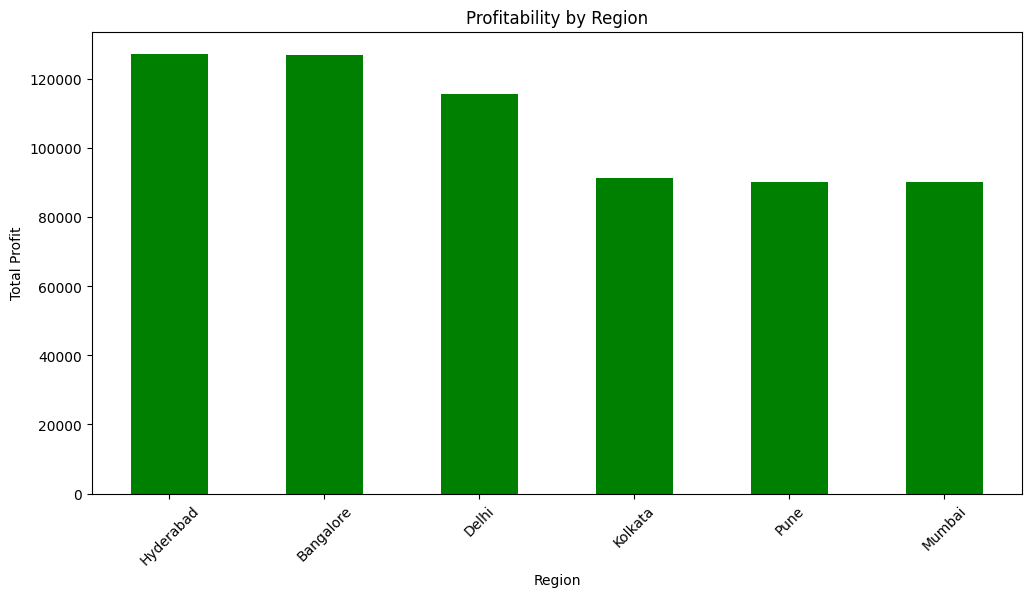

In [11]:
# Group by Region
region_profit = df.groupby('Region')['Profit_Recalc'].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
region_profit.plot(kind='bar', color='green')
plt.title("Profitability by Region")
plt.xlabel("Region")
plt.ylabel("Total Profit")
plt.xticks(rotation=45)
plt.show()

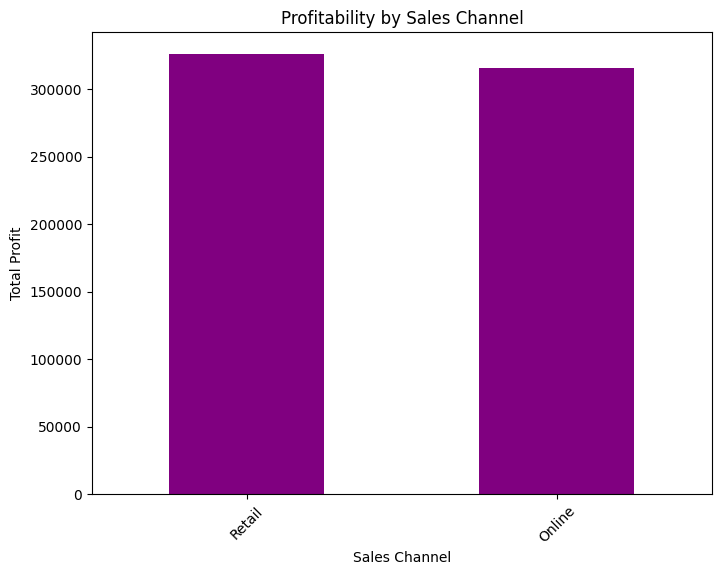

In [12]:
# Group by Sales Channel
channel_profit = df.groupby('Sales_Channel')['Profit_Recalc'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,6))
channel_profit.plot(kind='bar', color='purple')
plt.title("Profitability by Sales Channel")
plt.xlabel("Sales Channel")
plt.ylabel("Total Profit")
plt.xticks(rotation=45)
plt.show()

##  Customer Segment Analysis 

In [13]:
# Group by Gender Category
segment_perf = df.groupby('Gender_Category').agg({
    'Revenue_Calc':'sum',
    'Profit_Recalc':'sum'
}).sort_values('Revenue_Calc', ascending=False)

print(segment_perf)

                 Revenue_Calc  Profit_Recalc
Gender_Category                             
Men              2.148905e+06  239335.274118
Kids             1.990568e+06  205259.868397
Women            1.958905e+06  196932.933328


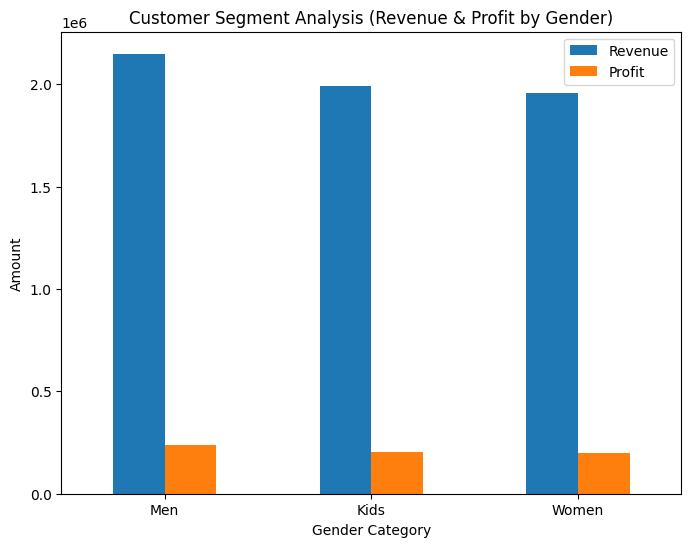

In [14]:
# Plot Revenue & Profit by Gender Category
segment_perf.plot(kind='bar', figsize=(8,6))
plt.title("Customer Segment Analysis (Revenue & Profit by Gender)")
plt.xlabel("Gender Category")
plt.ylabel("Amount")
plt.xticks(rotation=0)
plt.legend(["Revenue", "Profit"])
plt.show()

##  Regional Sales Insights

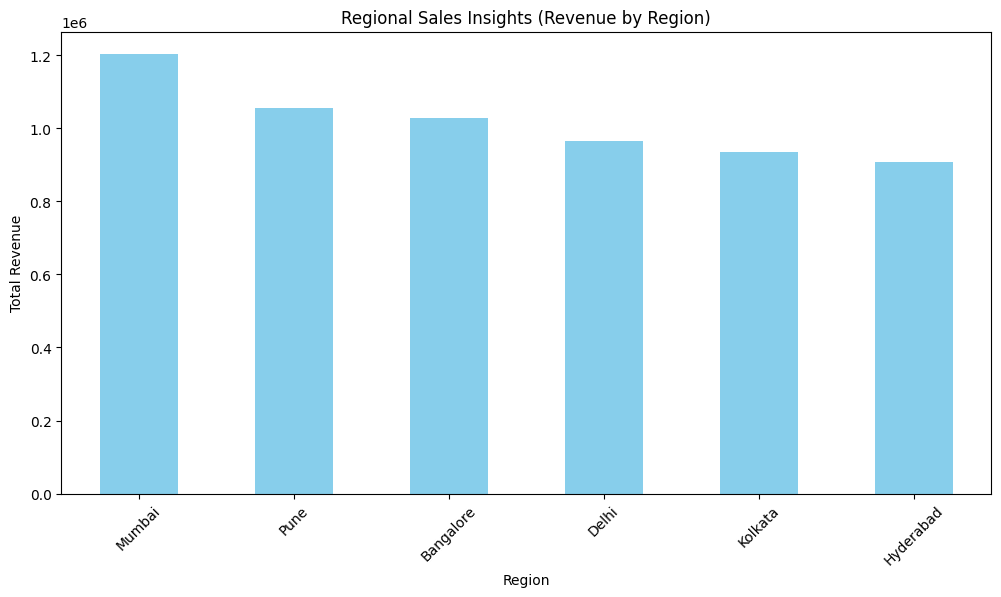

In [15]:
# Group by Region
region_revenue = df.groupby('Region')['Revenue_Calc'].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
region_revenue.plot(kind='bar', color='skyblue')
plt.title("Regional Sales Insights (Revenue by Region)")
plt.xlabel("Region")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()

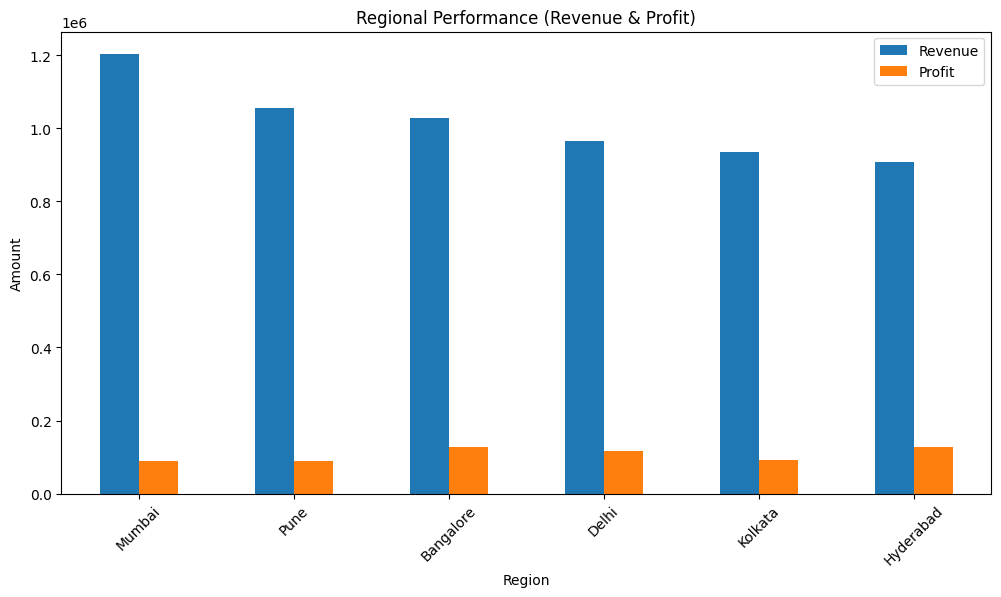

In [16]:
region_perf = df.groupby('Region').agg({
    'Revenue_Calc':'sum',
    'Profit_Recalc':'sum'
}).sort_values('Revenue_Calc', ascending=False)

region_perf.plot(kind='bar', figsize=(12,6))
plt.title("Regional Performance (Revenue & Profit)")
plt.xlabel("Region")
plt.ylabel("Amount")
plt.xticks(rotation=45)
plt.legend(["Revenue", "Profit"])
plt.show()